In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
import diffrax
from tqdm.notebook import tqdm
import random
import numpy as np

In [ ]:
spirals = jnp.load("spirals_100.npz")

print(spirals.files)

data_train = spirals["data_train"] # (10000, 100, 3)
data_val = spirals["data_validation"] # (10000, 100, 3)
data_test = spirals["data_test"] # (10000, 100, 3)

alpha_train = spirals["alpha_train"] # (10000, 1)
alpha_validation = spirals["alpha_validation"] # (10000, 1)

data_mean = jnp.mean(data_train, axis=(0, 1), keepdims=True)
data_std = jnp.std(data_train, axis=(0, 1), keepdims=True)

alpha_mean = jnp.mean(alpha_train)
alpha_std = jnp.std(alpha_train)

['data_train', 'alpha_train', 'data_validation', 'alpha_validation', 'data_test']


Alpha [-1.10760456]


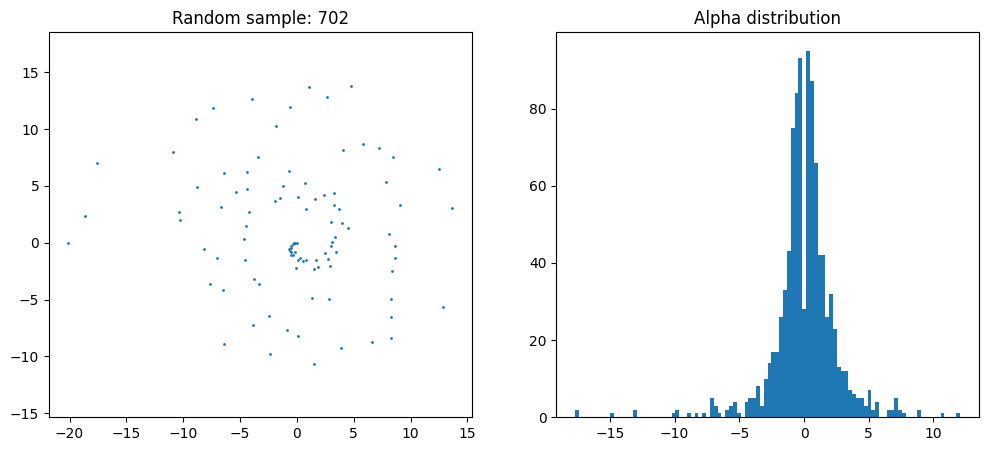

In [6]:
# data verification
rand_idx = random.randint(0, data_train.shape[0] - 1)

print("Alpha", alpha_train[rand_idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# scatter of a random training sample
x_values = data_train[rand_idx, :, 1].flatten() # (100,) 
y_values = data_train[rand_idx, :, 2].flatten() # (100,)

axes[0].scatter(x_values, y_values, s=1)
axes[0].set_title(f"Random sample: {rand_idx}")
axes[0].axis("equal")

# alpha distribution
axes[1].hist(alpha_train.flatten(), bins=100)
axes[1].set_title("Alpha distribution")
plt.show()

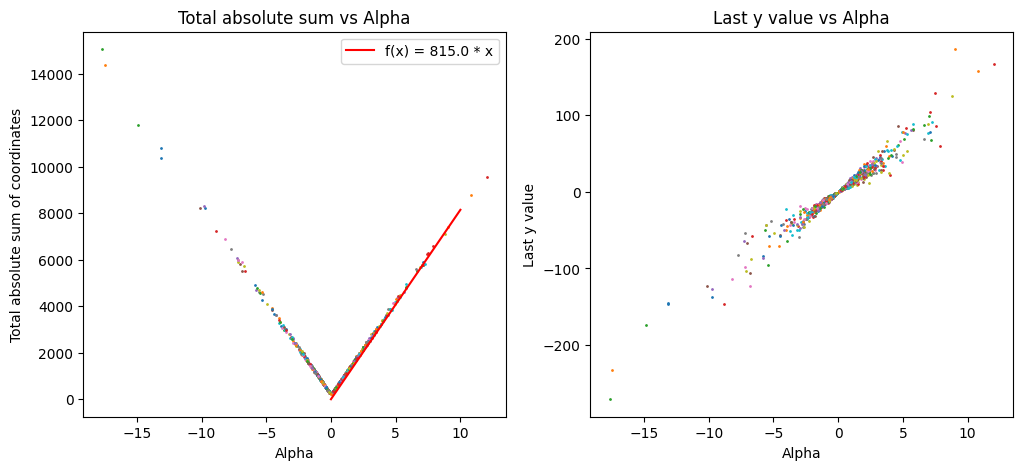

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# total absolute sum vs alpha
for i in range(data_train.shape[0]):
    total_abs_sum = jnp.sum(jnp.abs(data_train[i]))
    alpha_value = alpha_train[i]
    axs[0].scatter(alpha_value, total_abs_sum, s=1)

axs[0].set_xlabel("Alpha")
axs[0].set_ylabel("Total absolute sum of coordinates")
axs[0].set_title("Total absolute sum vs Alpha")

x_vals = jnp.linspace(0, 10, 100)
factor = 815.0
y_vals = factor * x_vals
axs[0].plot(x_vals, y_vals, color='red', linestyle='-', label=f'f(x) = {factor} * x')
axs[0].legend()

# last y value vs alpha
for i in range(data_train.shape[0]):
    last_y_value = data_train[i, -1, 1]
    alpha_value = alpha_train[i]
    axs[1].scatter(alpha_value, last_y_value, s=1)

axs[1].set_xlabel("Alpha")
axs[1].set_ylabel("Last y value")
axs[1].set_title("Last y value vs Alpha")

plt.show()

Processed 0 samples
(1000,)
(1000, 1)


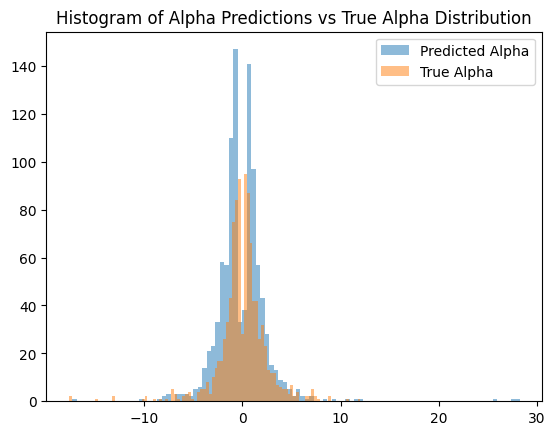

In [5]:
# simplest model
def simplest_model(xy):
    total_abs_sum = jnp.sum(jnp.abs(xy))
    last_y = xy[-1, 1]
    if last_y >= 0:
        return total_abs_sum / factor
    else:
        return - total_abs_sum / factor

alpha_test_preds = []
for i in range(data_test.shape[0]):
    xy = data_test[i]
    alpha_pred = simplest_model(xy)
    alpha_test_preds.append(alpha_pred)
    if i % 1000 == 0:
        print(f"Processed {i} samples")

alpha_test_preds = jnp.array(alpha_test_preds)
print(alpha_test_preds.shape)
print(alpha_train.shape)

# plot histogram of predictions
plt.hist(alpha_test_preds.flatten(), bins=100, alpha=0.5)
plt.hist(alpha_train.flatten(), bins=100, alpha=0.5)
plt.title("Histogram of Alpha Predictions vs True Alpha Distribution")
plt.legend(["Predicted Alpha", "True Alpha"])
plt.show()
